# Loan Risk Assessment Platform

## Exploratory Data Analysis (EDA)

### Objective
The objective of this notebook is to explore the loan prediction dataset, understand its structure, identify data quality issues, analyze feature distributions, and generate business insights that will guide feature engineering and model development.

In [1]:
# Standard Library
import warnings

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
warnings.filterwarnings("ignore")

# Visualization settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("../data/raw/train.csv")

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Dataset Overview

In [5]:
df.shape

(614, 13)

In [6]:
# column 
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [7]:
# Data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [8]:
#first five rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
# Random sample
df.sample(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
450,LP002446,Male,Yes,2,Not Graduate,No,2309,1255.0,125.0,360.0,0.0,Rural,N
356,LP002149,Male,Yes,2,Graduate,No,8333,3167.0,165.0,360.0,1.0,Rural,Y
174,LP001603,Male,Yes,0,Not Graduate,Yes,4344,736.0,87.0,360.0,1.0,Semiurban,N
460,LP002478,NaN,Yes,0,Graduate,Yes,2083,4083.0,160.0,360.0,NaN,Semiurban,Y
244,LP001811,Male,Yes,0,Not Graduate,No,3406,4417.0,123.0,360.0,1.0,Semiurban,Y


In [10]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [4]:
df.describe(include="object")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


# 2. Missing Value Analysis

In [5]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values = missing_values[missing_values["Missing Values"] > 0]
missing_values.sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage
Credit_History,50,8.143322
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Dependents,15,2.442997
Loan_Amount_Term,14,2.280130
Gender,13,2.117264
Married,3,0.488599


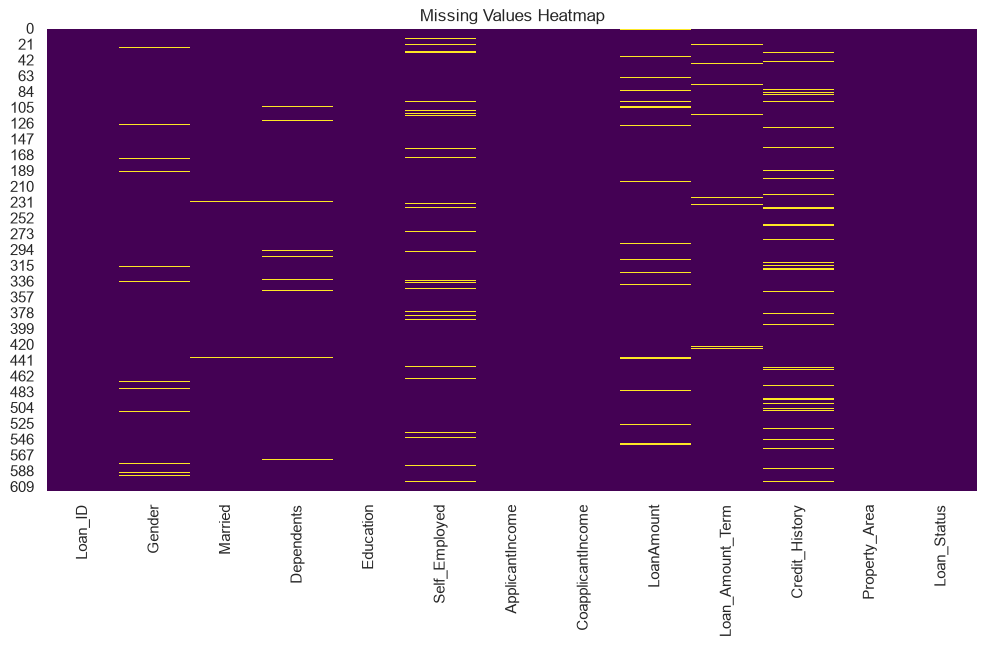

In [6]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")
plt.show()

Observations

The dataset contains missing values in several columns.
Credit_History has the highest number of missing values (50).
Self_Employed and LoanAmount also contain notable missing values.
Most missing values appear scattered throughout the dataset rather than concentrated in specific rows.
These missing values will need appropriate imputation before model training.

# 3. Duplicate Records

In this section, we check whether the dataset contains duplicate rows. Duplicate records can introduce bias into the analysis and model training, so they should be identified and handled appropriately.

In [3]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [4]:
df["Loan_ID"].duplicated().sum()

np.int64(0)

### Observations

- No duplicate rows were found in the dataset.
- Each loan application appears to represent a unique record.
- No duplicate removal is required at this stage.

#Target Variable Analysis
So before training any classifier, we always ask: Is the target variable balanced or imbalanced?

In [5]:
df["Loan_Status"].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [6]:
df["Loan_Status"].value_counts(normalize=True) * 100

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

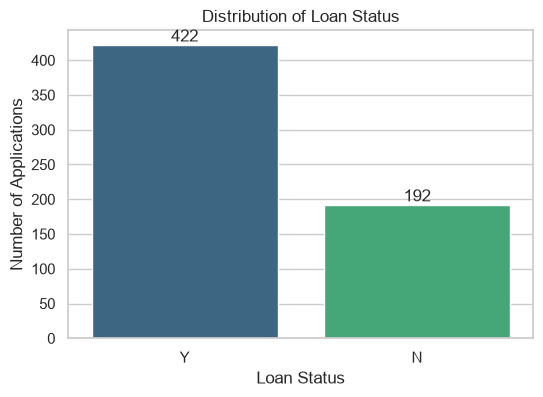

In [8]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data = df,
    x="Loan_Status",
    palette="viridis"
)


for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()

### Observations

- The dataset contains **422 approved loans (Y)** and **192 rejected loans (N)**.
- Approximately **68.7%** of the applications are approved, while **31.3%** are rejected.
- The target variable is **slightly imbalanced**, with approved loans being the majority class.
- Although the imbalance is not severe, it should be considered during model evaluation.

### Business Interpretation

The historical data indicates that the bank has approved a larger proportion of loan applications than it has rejected. This suggests that loan approvals are more common in the dataset.

Since the classes are moderately imbalanced, relying solely on accuracy could overestimate model performance. Therefore, additional evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC will be used to ensure the model performs well for both approved and rejected loan applications.

Univariate analysis (analysis of 1 type of feature)
we'll divide the features into two groups: Numerical Features, Categorical Features

In [9]:
# Numerical features
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical features
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Categorical Features:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


# 5.1 Applicant Income Analysis

### Objective

Analyze the distribution of applicants' income to understand its spread, identify outliers, and detect any skewness that may influence feature engineering and model performance.

In [10]:
df["ApplicantIncome"].describe()

count      614.000000
mean      5403.459283
std       6109.041673
min        150.000000
25%       2877.500000
50%       3812.500000
75%       5795.000000
max      81000.000000
Name: ApplicantIncome, dtype: float64

In [11]:
print(f"Median : {df['ApplicantIncome'].median():.2f}")
print(f"Skewness : {df['ApplicantIncome'].skew():.2f}")
print(f"Kurtosis : {df['ApplicantIncome'].kurt():.2f}")

Median : 3812.50
Skewness : 6.54
Kurtosis : 60.54


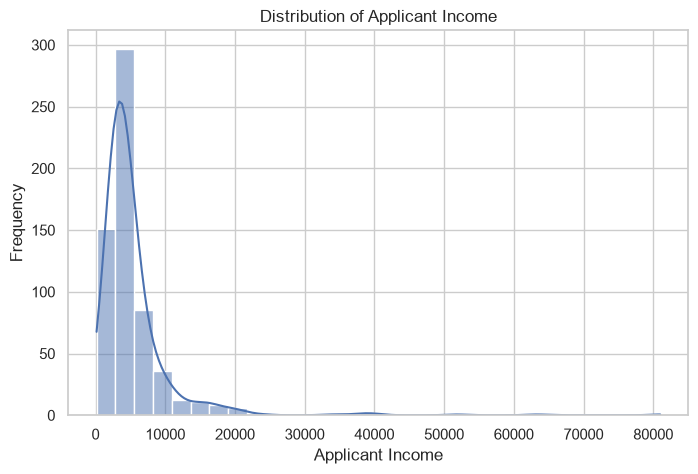

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="ApplicantIncome",
    bins=30,
    kde=True
)

plt.title("Distribution of Applicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")

plt.show()


| Skewness | Interpretation          |
| -------: | ----------------------- |
|      ≈ 0 | Symmetric               |
| 0.5 to 1 | Moderately right-skewed |
|      > 1 | Highly right-skewed     |


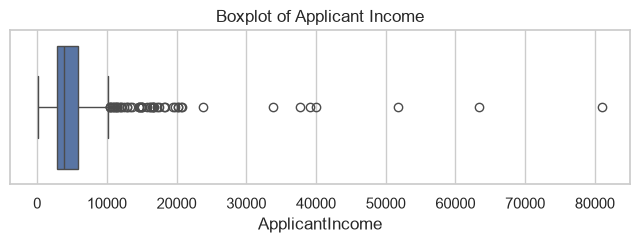

In [13]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["ApplicantIncome"]
)

plt.title("Boxplot of Applicant Income")

plt.show()

### Observations

- The average applicant income (₹5,403) is considerably higher than the median income (₹3,812), indicating a positively skewed distribution.
- The histogram shows that most applicants fall within the lower income range, while a small number of applicants have exceptionally high incomes.
- The boxplot reveals several extreme outliers in applicant income.
- A skewness value of **6.54** confirms that the distribution is highly right-skewed.
- The high kurtosis value (**60.54**) indicates heavy tails and the presence of numerous extreme observations.

### Business Interpretation

The majority of loan applicants belong to the low-to-middle income group, while a small proportion of high-income applicants creates a long upper tail in the distribution. These applicants may represent a distinct customer segment and should not be treated as erroneous records without further investigation. Since the income distribution is highly skewed, statistical measures such as the median provide a better representation of a typical applicant than the mean.

# 5. Numerical Feature Analysis

## Objective

Analyze the numerical features to understand their statistical properties, identify missing values, detect skewness and outliers, and determine which features require preprocessing before model development.

In [3]:
# Numerical features used for statistical analysis
numerical_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

# Binary categorical feature
binary_feature = "Credit_History"

print(numerical_features)

['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']


In [9]:
summary = df[numerical_features].describe().T
summary

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0


In [10]:


summary["Median"] = df[numerical_features].median()
summary["Skewness"] = df[numerical_features].skew()
summary["Kurtosis"] = df[numerical_features].kurt()
summary["Missing"] = df[numerical_features].isnull().sum()

summary

,count,mean,std,min,25%,50%,75%,max,Median,Skewness,Kurtosis,Missing
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0,3812.5,6.539513,60.540676,0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0,1188.5,7.491531,84.956384,0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0,128.0,2.677552,10.401533,22
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0,360.0,-2.362414,6.673474,14


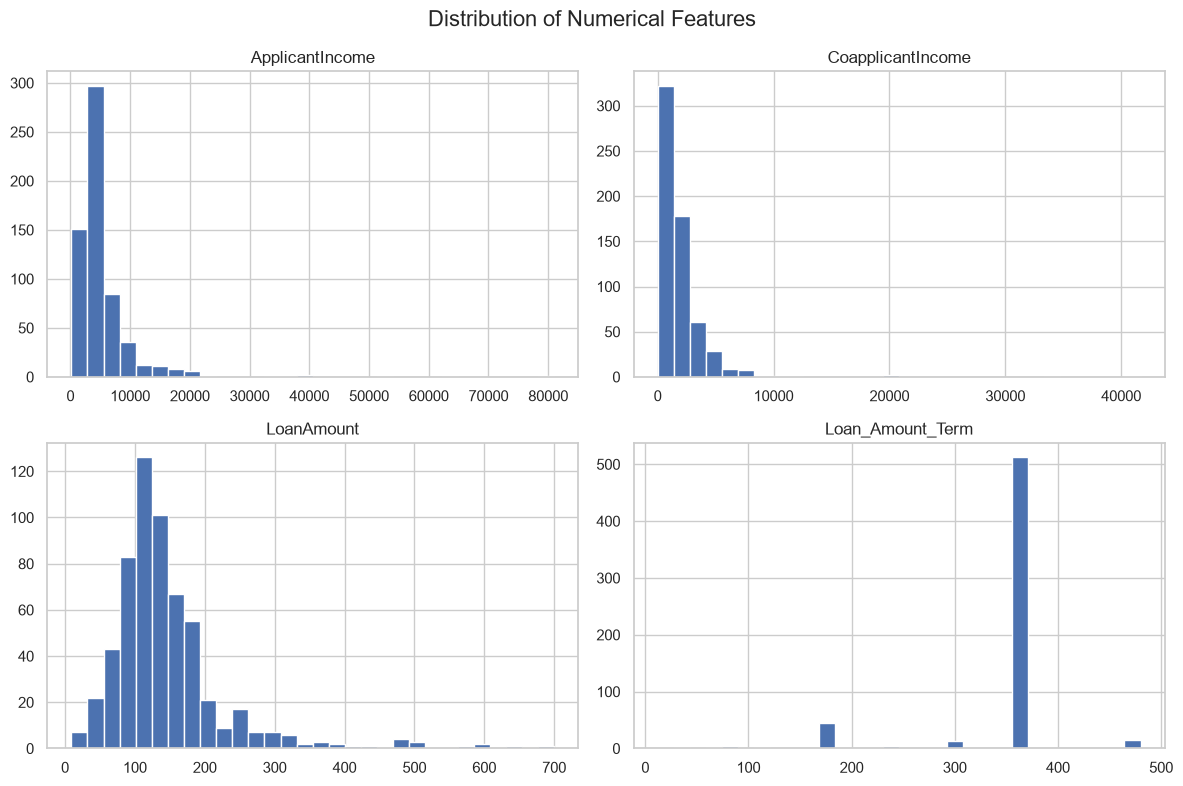

In [11]:
df[numerical_features].hist(
    figsize=(12,8),
    bins=30
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.tight_layout()

plt.show()

### Observations

- ApplicantIncome and CoapplicantIncome exhibit highly right-skewed distributions with numerous extreme outliers.
- A substantial proportion of applicants have zero co-applicant income, suggesting many individuals applied without a co-applicant.
- LoanAmount is moderately right-skewed, with most loan amounts concentrated around 100–150 units and relatively fewer high-value loans.
- Loan_Amount_Term is concentrated at 360 months, indicating that most approved loan terms span approximately 30 years.
- Several numerical features contain outliers, which should be investigated before model development.

### Business Interpretation

The applicant population primarily consists of low- to middle-income individuals, while a smaller segment earns significantly higher incomes. Many applicants apply independently without a co-applicant, making the combined household income an important feature to engineer. The dominance of 30-year loan terms reflects standard lending practices, while the presence of skewness and outliers suggests that appropriate preprocessing techniques may improve model performance.

### Key Takeaway

Most numerical features are positively skewed and contain outliers. Feature engineering (such as TotalIncome) and careful preprocessing will play an important role in building a robust loan prediction model.

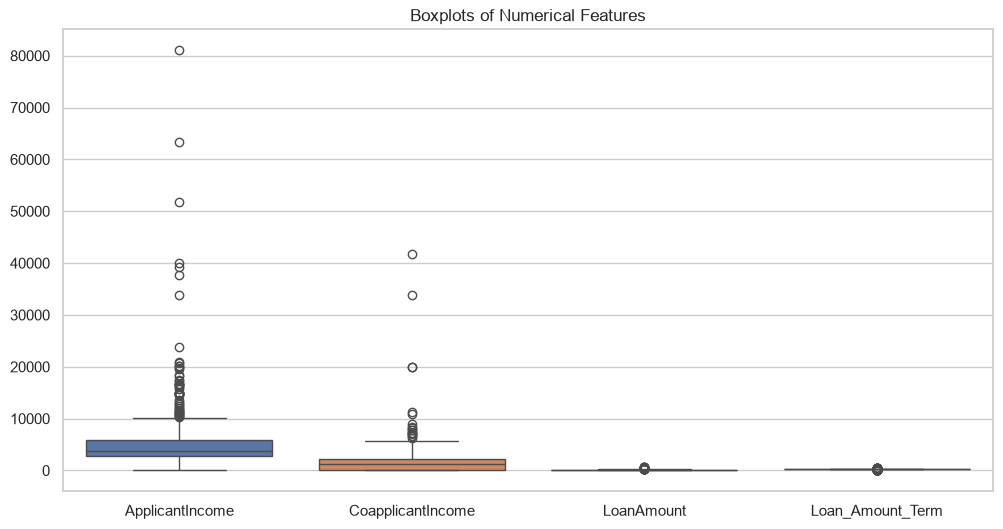

In [12]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[numerical_features])

plt.title("Boxplots of Numerical Features")

plt.show()

# 6. Categorical Feature Analysis

## Objective

Analyze the categorical features to understand their category distributions, identify dominant categories, detect missing values, and uncover characteristics of loan applicants that may influence loan approval.

In [14]:
categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Credit_History",
    "Loan_Status"
]

In [15]:
summary_cat = pd.DataFrame({
    "Unique Values": df[categorical_features].nunique(),
    "Missing Values": df[categorical_features].isnull().sum(),
    "Most Frequent": df[categorical_features].mode().iloc[0]
})

summary_cat

,Unique Values,Missing Values,Most Frequent
Gender,2,13,Male
Married,2,3,Yes
Dependents,4,15,0
Education,2,0,Graduate
Self_Employed,2,32,No
Property_Area,3,0,Semiurban
Credit_History,2,50,1.0
Loan_Status,2,0,Y


In [16]:
for feature in categorical_features:
    print("=" * 50)
    print(feature)
    print(df[feature].value_counts(dropna=False))
    print()

Gender
Gender
Male      489
Female    112
NaN        13
Name: count, dtype: int64

Married
Married
Yes    398
No     213
NaN      3
Name: count, dtype: int64

Dependents
Dependents
0      345
1      102
2      101
3+      51
NaN     15
Name: count, dtype: int64

Education
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

Self_Employed
Self_Employed
No     500
Yes     82
NaN     32
Name: count, dtype: int64

Property_Area
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

Credit_History
Credit_History
1.0    475
0.0     89
NaN     50
Name: count, dtype: int64

Loan_Status
Loan_Status
Y    422
N    192
Name: count, dtype: int64



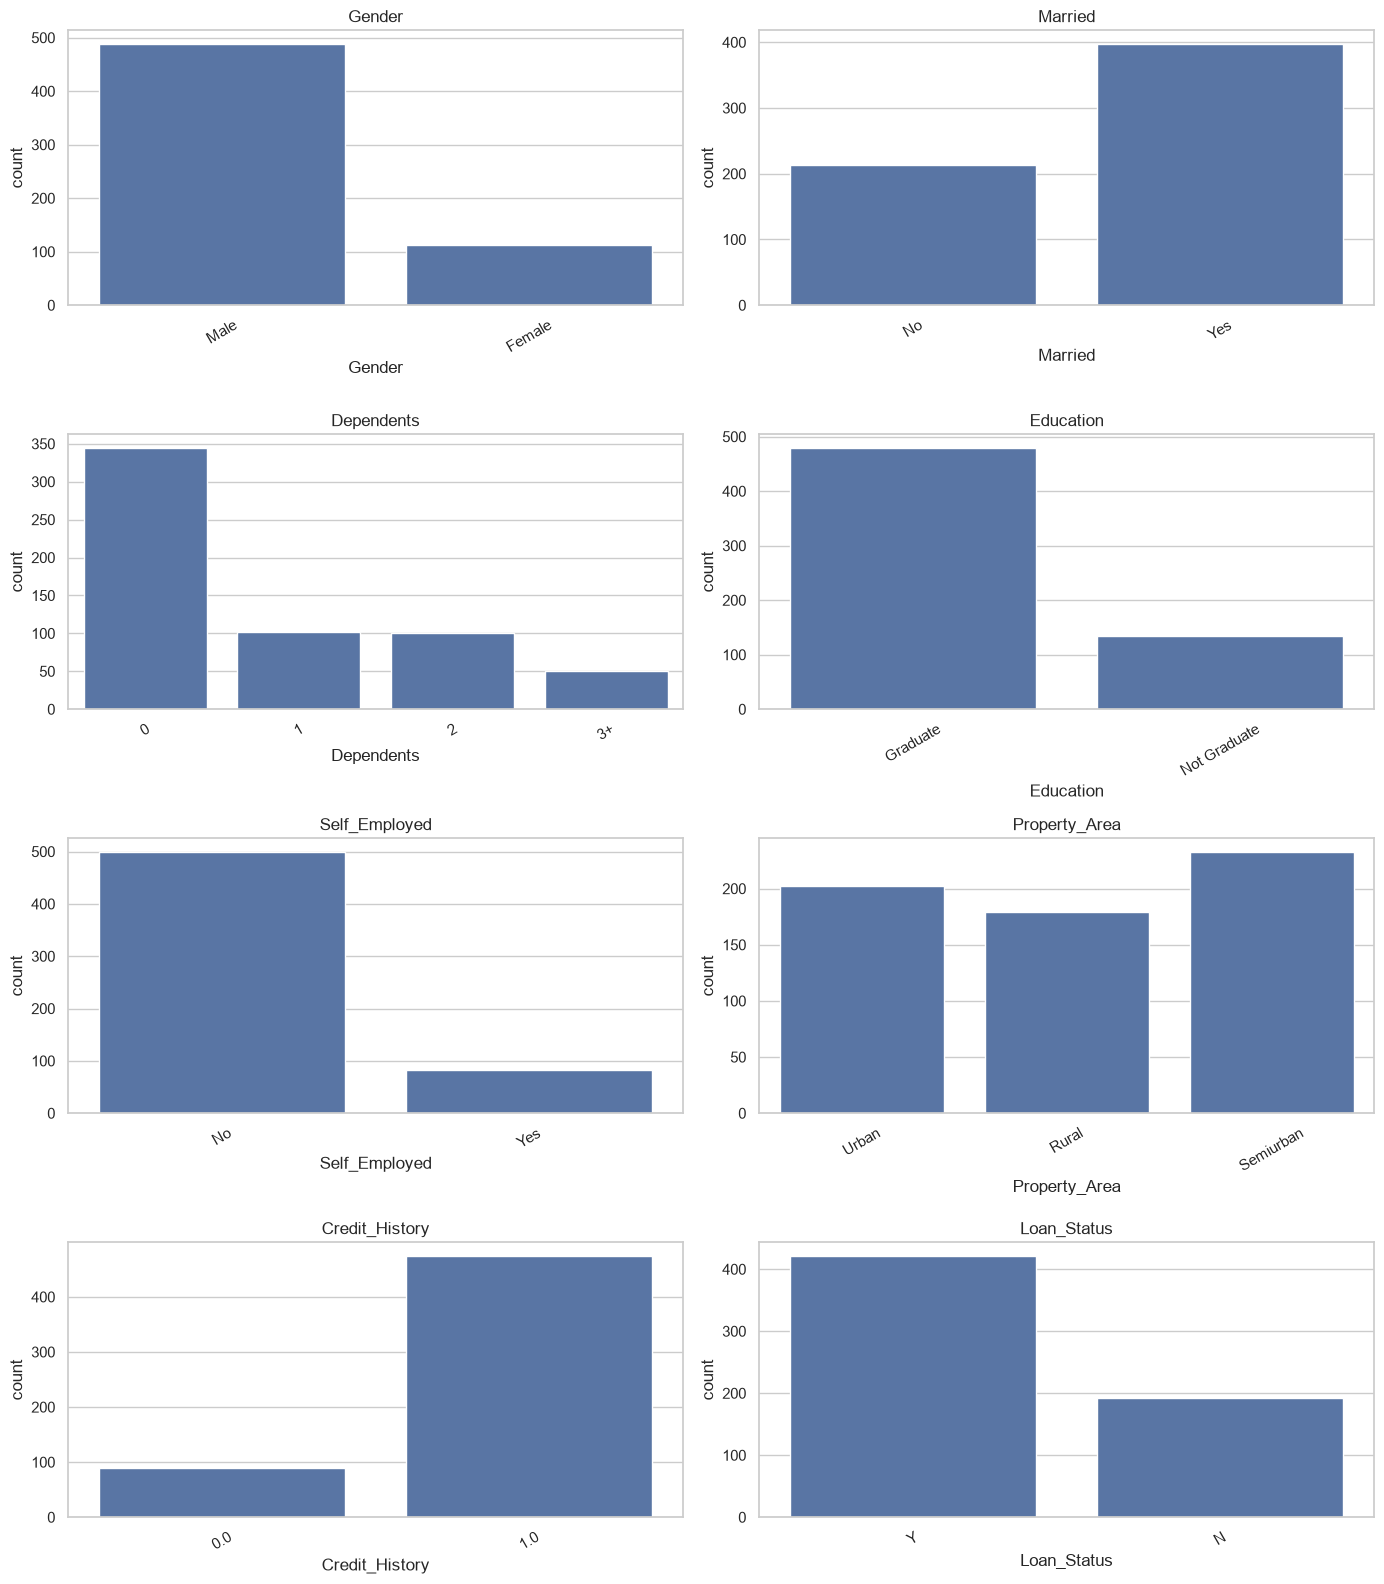

In [17]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.countplot(
        data=df,
        x=feature,
        ax=axes[i]
    )

    axes[i].set_title(feature)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()

plt.show()

### Observations

- The dataset is predominantly composed of **male applicants**, while female applicants represent a much smaller proportion.
- Most applicants are **married**, indicating that family applicants constitute a significant portion of the loan applications.
- A large number of applicants have **no dependents**, whereas applicants with three or more dependents are relatively uncommon.
- The majority of applicants are **graduates**, suggesting that educated individuals form the largest applicant group.
- Most applicants are **not self-employed**, indicating that salaried individuals dominate the dataset.
- Applications are fairly distributed across different property areas, with **Semiurban** having the highest number of applications.
- A large majority of applicants have a **positive credit history (1.0)**, while comparatively fewer applicants have a poor credit history (0.0).
- The target variable shows that **approved loans (Y)** outnumber rejected loans (N), indicating a moderately imbalanced dataset.

### Business Interpretation

The applicant pool primarily consists of married, graduate, salaried individuals with no dependents. Most applicants also possess a positive credit history, suggesting that the bank has historically received applications from relatively low-risk customers. The balanced representation across property areas provides an opportunity to evaluate whether geographical location influences loan approval decisions.


### Key Takeaway

The categorical features reveal the demographic and financial profile of the applicants. Features such as Credit_History, Education, Property_Area, and Marital Status appear promising for further investigation, while the target variable exhibits only a moderate class imbalance.

Bivariate Analysis
Group 1: Strongest Predictors
Credit_History vs Loan_Status ⭐⭐⭐⭐⭐
TotalIncome vs Loan_Status ⭐⭐⭐⭐ (after feature engineering)
LoanAmount vs Loan_Status ⭐⭐⭐⭐

Group 2: Demographic Features
Gender vs Loan_Status
Married vs Loan_Status
Education vs Loan_Status
Self_Employed vs Loan_Status
Dependents vs Loan_Status
Property_Area vs Loan_Status

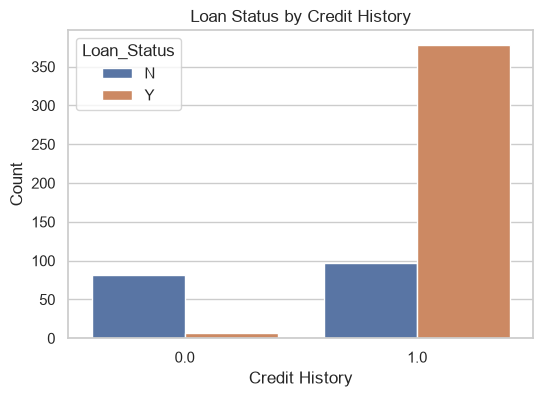

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Credit_History",
    hue="Loan_Status"
)

plt.title("Loan Status by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Count")

plt.show()

Observation
Applicants with Credit_History = 1 have a very high loan approval rate.
Applicants with Credit_History = 0 are mostly rejected.
This is the strongest pattern we've seen so far.

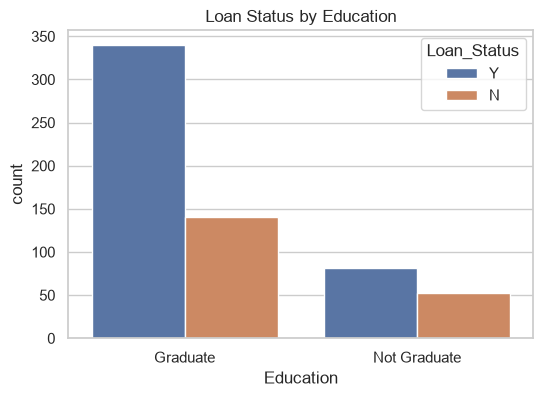

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Education",
    hue="Loan_Status"
)

plt.title("Loan Status by Education")

plt.show()

Education alone doesn't appear to strongly influence loan approval. The higher approvals may simply be because more graduates applied. 
Education is likely a weaker predictor than Credit_History.

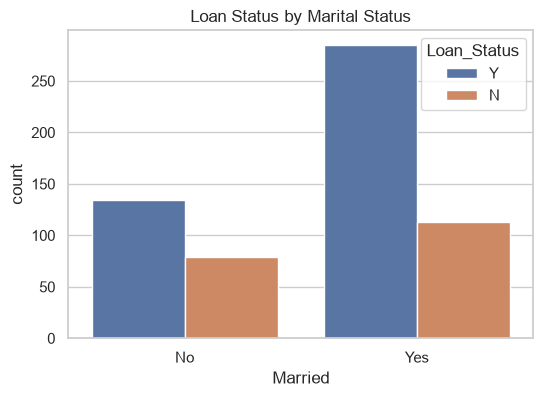

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Married",
    hue="Loan_Status"
)

plt.title("Loan Status by Marital Status")

plt.show()

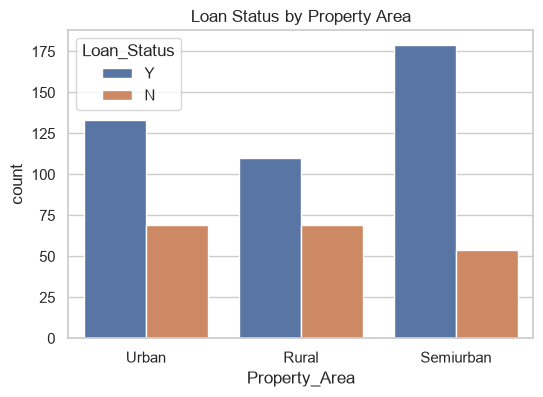

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Property_Area",
    hue="Loan_Status"
)

plt.title("Loan Status by Property Area")

plt.show()

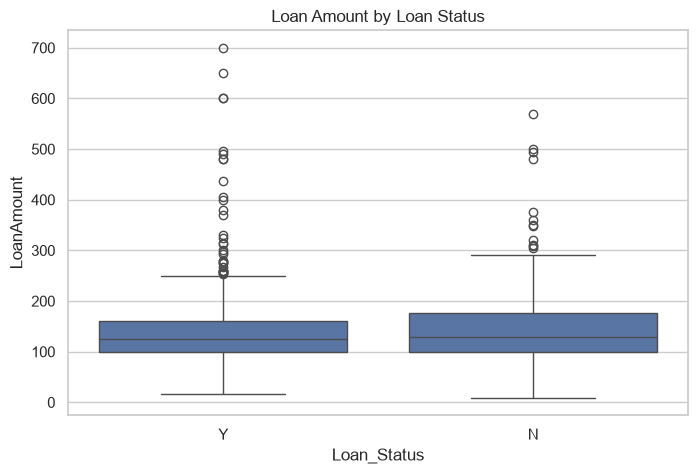

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Loan_Status",
    y="LoanAmount"
)

plt.title("Loan Amount by Loan Status")

plt.show()

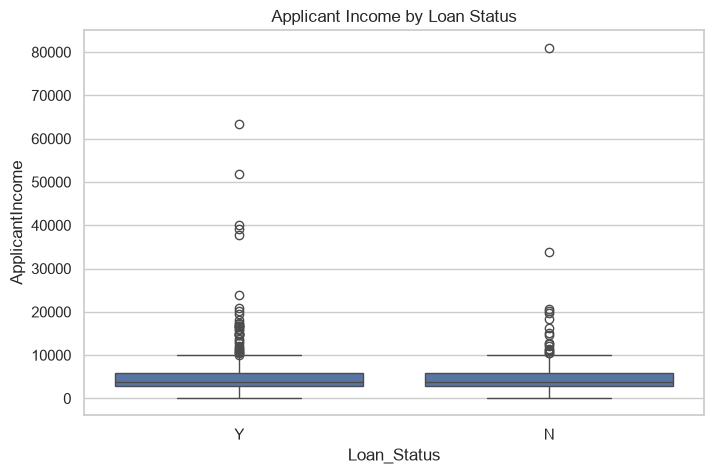

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Loan_Status",
    y="ApplicantIncome"
)

plt.title("Applicant Income by Loan Status")

plt.show()

In [24]:
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]

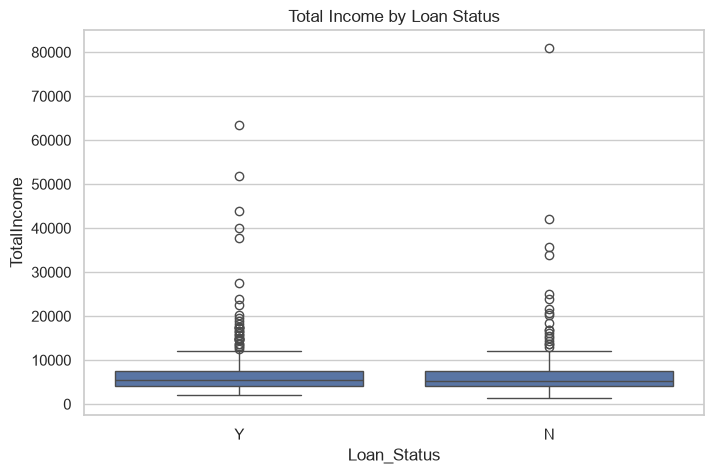

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Loan_Status",
    y="TotalIncome"
)

plt.title("Total Income by Loan Status")

plt.show()

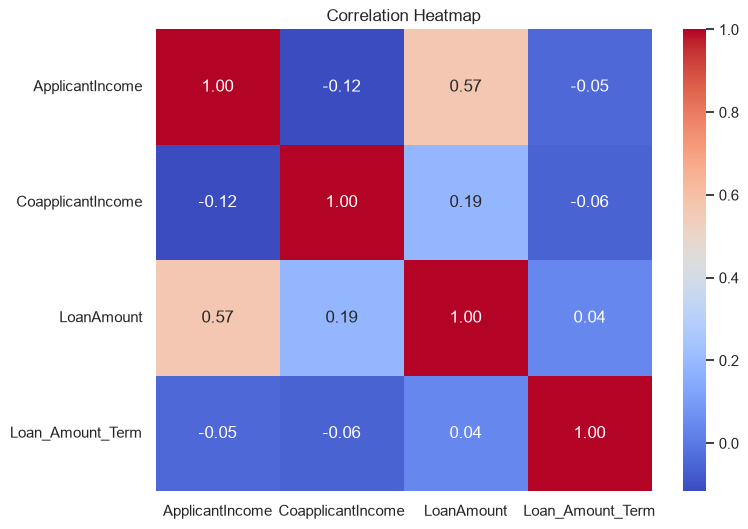

In [26]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Observations
ApplicantIncome and LoanAmount have a moderate positive correlation (0.57).
CoapplicantIncome has a weak correlation (0.19) with LoanAmount.
Loan_Amount_Term has almost no correlation with the other numerical features.
No pair of features shows a very high correlation (>|0.8|), so multicollinearity is not a concern

Business Interpretation

Applicants with higher incomes generally tend to apply for larger loans. However, most numerical features are only weakly correlated, indicating that loan approval is likely influenced by multiple factors rather than a single numerical feature

No strong multicollinearity exists among the numerical features, so all can be retained for model development.

## EDA Summary

- The dataset contains **614 records** and **13 features**.
- Missing values are present in multiple columns and will require preprocessing.
- No duplicate records were found.
- The target variable is moderately imbalanced (~69% approved, ~31% rejected).
- Income-related features are highly right-skewed and contain several outliers.
- Most applicants are male, married, graduates, and not self-employed.
- Credit_History appears to be the strongest predictor of loan approval.
- Features such as Education, Gender, Property_Area, ApplicantIncome, LoanAmount, and TotalIncome do not individually show a strong relationship with Loan_Status.
- No severe multicollinearity exists among numerical features.